# Assignment Week 5 - Model Selection and Regularization

## Create Synthetic Dataset

In [2]:
import numpy as np

np.random.seed(42)

n_samples = 40

X = np.sort(6 * np.random.rand(n_samples, 1), axis=0)


y_true = np.sin(X).ravel()

y = y_true + np.random.normal(0, 0.8, n_samples)

## Dataset Visualization

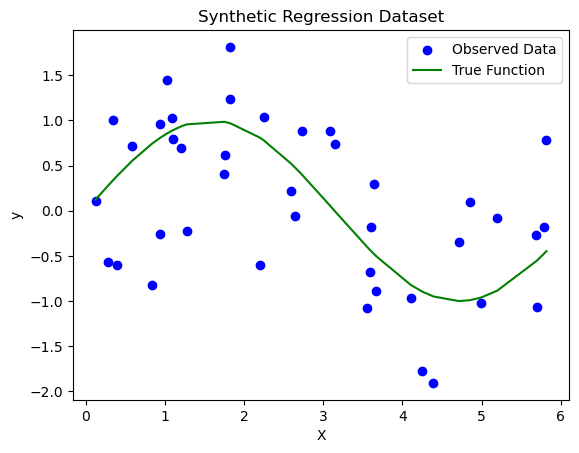

In [3]:
import matplotlib.pyplot as plt

plt.scatter(X, y, color="blue", label="Observed Data")
plt.plot(X, y_true, color="green", label="True Function")

plt.title("Synthetic Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

## Splitting Data

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## Regression Model

In [5]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("linear", LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('poly', PolynomialFeatures(degree=15)),
                ('linear', LinearRegression())])

## Model Evaluation

In [6]:
from sklearn.metrics import r2_score, mean_squared_error

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("Training R2:", train_r2)
print("Testing R2:", test_r2)

print("Training RMSE:", train_rmse)
print("Testing RMSE:", test_rmse)

Training R2: 0.6509614724485535
Testing R2: -0.26794870879469346
Training RMSE: 0.5173550624644478
Testing RMSE: 0.9057824414318774


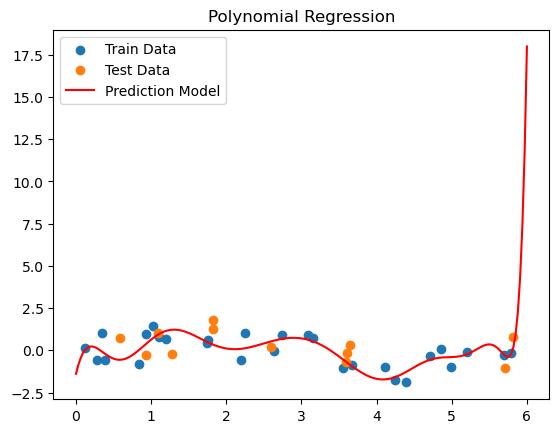

In [7]:
X_plot = np.linspace(0, 6, 200).reshape(-1,1)
y_plot = model.predict(X_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")

plt.plot(X_plot, y_plot, color="red", label="Prediction Model")

plt.title("Polynomial Regression")
plt.legend()
plt.show()

## Cross-Validation

In [8]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross Validation Scores: [-6.56430577e+02 -5.72536783e-01 -4.29251370e+01 -1.01954258e+01
 -1.52723592e+12]
Mean CV Score: -305447184704.1996


# Model Improvement

### Method 1: Reduce Polynomial Degree 4

In [9]:
# Method 1: Reduce Polynomial Degree to 4
model_reduced = Pipeline([
    ("poly", PolynomialFeatures(degree=4)),
    ("linear", LinearRegression())
])

model_reduced.fit(X_train, y_train)

# Predictions
y_train_pred_reduced = model_reduced.predict(X_train)
y_test_pred_reduced = model_reduced.predict(X_test)

# Evaluation
train_r2_reduced = r2_score(y_train, y_train_pred_reduced)
test_r2_reduced = r2_score(y_test, y_test_pred_reduced)
train_rmse_reduced = np.sqrt(mean_squared_error(y_train, y_train_pred_reduced))
test_rmse_reduced = np.sqrt(mean_squared_error(y_test, y_test_pred_reduced))

# Cross-Validation
cv_scores_reduced = cross_val_score(model_reduced, X, y, cv=5, scoring="r2")

print("=== Method 1: Reduced Polynomial Degree (Degree = 4) ===")
print("Training R2:", round(train_r2_reduced, 4))
print("Testing R2:", round(test_r2_reduced, 4))
print("Training RMSE:", round(train_rmse_reduced, 4))
print("Testing RMSE:", round(test_rmse_reduced, 4))
print("CV Scores:", cv_scores_reduced.round(4))
print("Mean CV Score:", round(cv_scores_reduced.mean(), 4))

=== Method 1: Reduced Polynomial Degree (Degree = 4) ===
Training R2: 0.411
Testing R2: 0.277
Training RMSE: 0.6721
Testing RMSE: 0.684
CV Scores: [  -0.5231   -0.4442   -0.6182   -1.5823 -105.3076]
Mean CV Score: -21.6951


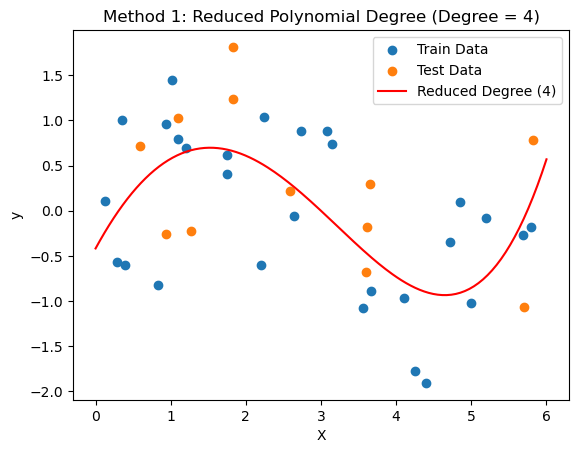

In [10]:
# Visualization for Method 1
X_plot = np.linspace(0, 6, 200).reshape(-1, 1)
y_plot_reduced = model_reduced.predict(X_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_plot, y_plot_reduced, color="red", label="Reduced Degree (4)")

plt.title("Method 1: Reduced Polynomial Degree (Degree = 4)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Method 2: Ridge Regularization (Degree = 15, Alpha = 1)

In [11]:
# Method 2: Ridge Regularization with Polynomial Degree 15
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

model_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=5)),
    # ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1))
])

model_ridge.fit(X_train, y_train)

# Predictions
y_train_pred_ridge = model_ridge.predict(X_train)
y_test_pred_ridge = model_ridge.predict(X_test)

# Evaluation
train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)
train_rmse_ridge = np.sqrt(mean_squared_error(y_train, y_train_pred_ridge))
test_rmse_ridge = np.sqrt(mean_squared_error(y_test, y_test_pred_ridge))

# Cross-Validation
cv_scores_ridge = cross_val_score(model_ridge, X, y, cv=5, scoring="r2")

print("=== Method 2: Ridge Regularization (Degree = 15, Alpha = 1) ===")
print("Training R2:", round(train_r2_ridge, 4))
print("Testing R2:", round(test_r2_ridge, 4))
print("Training RMSE:", round(train_rmse_ridge, 4))
print("Testing RMSE:", round(test_rmse_ridge, 4))
print("CV Scores:", cv_scores_ridge.round(4))
print("Mean CV Score:", round(cv_scores_ridge.mean(), 4))

=== Method 2: Ridge Regularization (Degree = 15, Alpha = 1) ===
Training R2: 0.4162
Testing R2: 0.2721
Training RMSE: 0.6691
Testing RMSE: 0.6863
CV Scores: [ -1.1649  -0.4772  -0.6132  -1.8735 -57.2071]
Mean CV Score: -12.2672


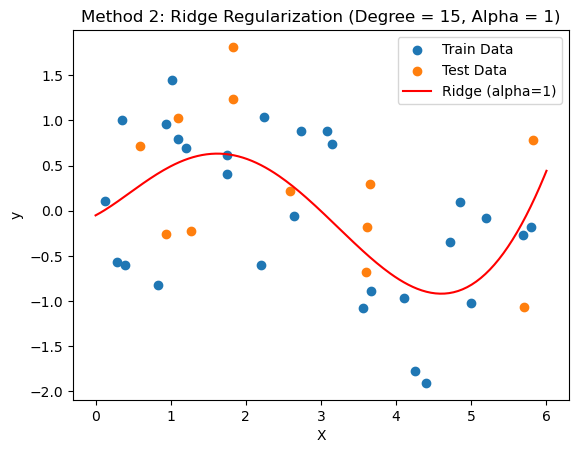

In [15]:
# Visualization for Method 2
y_plot_ridge = model_ridge.predict(X_plot)

plt.scatter(X_train, y_train, label="Train Data")
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_plot, y_plot_ridge, color="red", label="Ridge (alpha=1)")

plt.title("Method 2: Ridge Regularization (Degree = 15, Alpha = 1)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

### Comparison: All Models

In [13]:
# Comparison Table
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline (Degree 15)", "Reduced Degree (Degree 4)", "Ridge Regularization (Degree 15)"],
    "Train R2": [train_r2, train_r2_reduced, train_r2_ridge],
    "Test R2": [test_r2, test_r2_reduced, test_r2_ridge],
    "Train RMSE": [train_rmse, train_rmse_reduced, train_rmse_ridge],
    "Test RMSE": [test_rmse, test_rmse_reduced, test_rmse_ridge],
    "Mean CV Score": [cv_scores.mean(), cv_scores_reduced.mean(), cv_scores_ridge.mean()]
})

comparison = comparison.round(4)
print("=== Model Comparison Table ===")
print(comparison.to_string(index=False))

=== Model Comparison Table ===
                           Model  Train R2  Test R2  Train RMSE  Test RMSE  Mean CV Score
            Baseline (Degree 15)    0.6510  -0.2679      0.5174     0.9058  -3.054472e+11
       Reduced Degree (Degree 4)    0.4110   0.2770      0.6721     0.6840  -2.169510e+01
Ridge Regularization (Degree 15)    0.4162   0.2721      0.6691     0.6863  -1.226720e+01


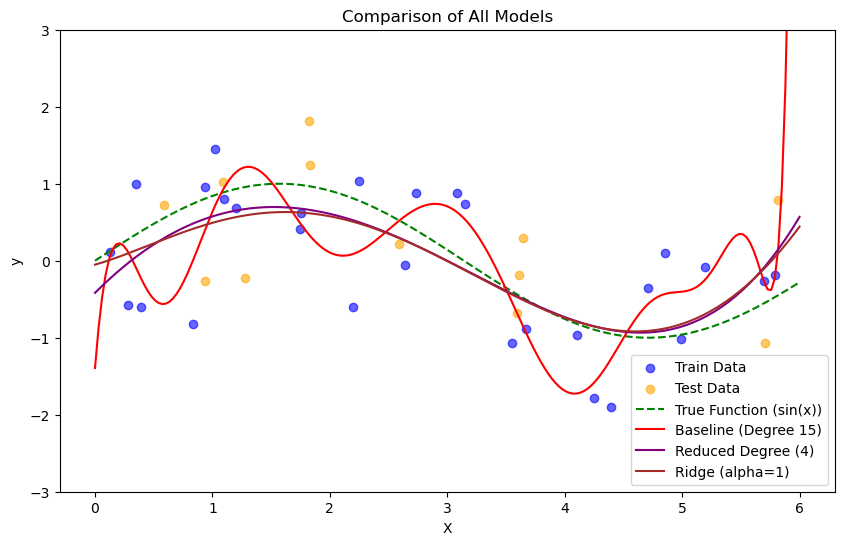

In [14]:
# Comparison Visualization: All Models
y_plot_baseline = model.predict(X_plot)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, color="blue", label="Train Data", alpha=0.6)
plt.scatter(X_test, y_test, color="orange", label="Test Data", alpha=0.6)
plt.plot(X_plot, np.sin(X_plot), color="green", linestyle="--", label="True Function (sin(x))")
plt.plot(X_plot, y_plot_baseline, color="red", label="Baseline (Degree 15)")
plt.plot(X_plot, y_plot_reduced, color="purple", label="Reduced Degree (4)")
plt.plot(X_plot, y_plot_ridge, color="brown", label="Ridge (alpha=1)")

plt.ylim(-3, 3)
plt.title("Comparison of All Models")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()